In [1]:
from Matrix_graph import ws_opinion_graph, create_matrix_rep, GraphState, add_media_nodes_polar_no_overlap,add_disinfo_nodes,state_to_graph, er_opinion_graph
from Matrix_simuleringslogik import time_step_no_media_no_disinfo, simpel_simulering, data_processing,in_and_out_degree_sum,cross_type_degree
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
n, k = 10000, 140
p_er = k / (n - 1)

In [3]:
ws_Scenarie4 = ws_opinion_graph(n,k,seed = 11)
ws_Scenarie4matrix = create_matrix_rep(ws_Scenarie4)

ws_MedierScenarie4 = add_media_nodes_polar_no_overlap(ws_Scenarie4matrix,1,seed = 11)

In [4]:
er_Scenarie4 = er_opinion_graph(n,p_er,seed = 11)
er_Scenarie4matrix = create_matrix_rep(er_Scenarie4)
er_MedierScenarie4 = add_media_nodes_polar_no_overlap(er_Scenarie4matrix,1,seed = 11)

In [5]:
ws_MedierScenarie4.opinions, ws_MedierScenarie4_sim_results,ws_Scenarie4_startcond,ws_Scenarie4_endcond= simpel_simulering(ws_MedierScenarie4,200)

er_MedierScenarie4.opinions, er_MedierScenarie4_sim_results,er_Scenarie4_startcond,er_Scenarie4_endcond= simpel_simulering(er_MedierScenarie4,200)


Simulating: 100%|██████████| 200/200 [00:12<00:00, 16.01it/s]


In [6]:
# ws
ws_maskhumanScenarie4 = ws_MedierScenarie4.type == "Human"
ws_Hoved_average_opinionresult, ws_Hoved_average_distance_to_the_mean_result = data_processing(ws_MedierScenarie4_sim_results,ws_maskhumanScenarie4)

# er
er_maskhumanScenarie4 = er_MedierScenarie4.type == "Human"
er_Hoved_average_opinionresult, er_Hoved_average_distance_to_the_mean_result = data_processing(er_MedierScenarie4_sim_results,er_maskhumanScenarie4)

In [7]:
ws_binsScenarie4 = np.histogram_bin_edges(np.concatenate([ws_Scenarie4_startcond[ws_maskhumanScenarie4], ws_Scenarie4_endcond[ws_maskhumanScenarie4]]), bins=100)

er_binsScenarie4 = np.histogram_bin_edges(np.concatenate([er_Scenarie4_startcond[er_maskhumanScenarie4], er_Scenarie4_endcond[er_maskhumanScenarie4]]), bins=100)


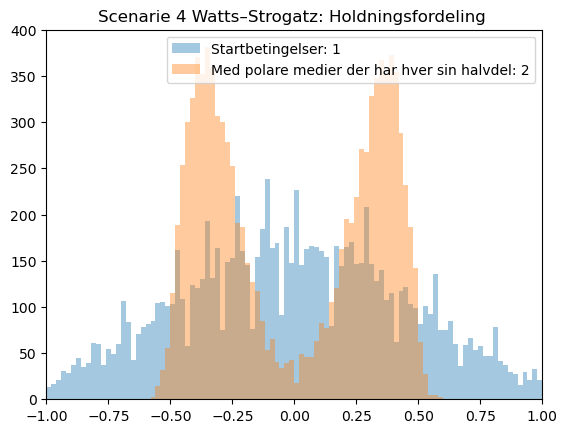

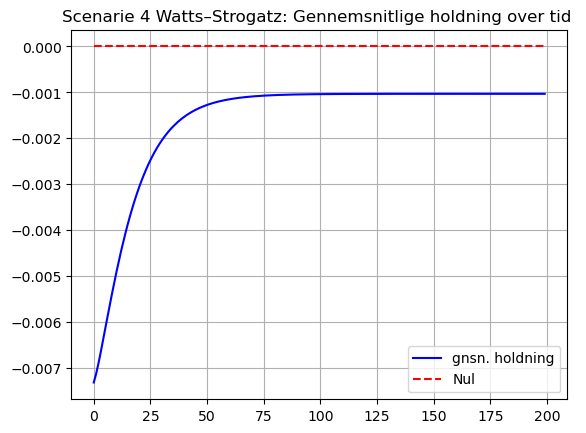

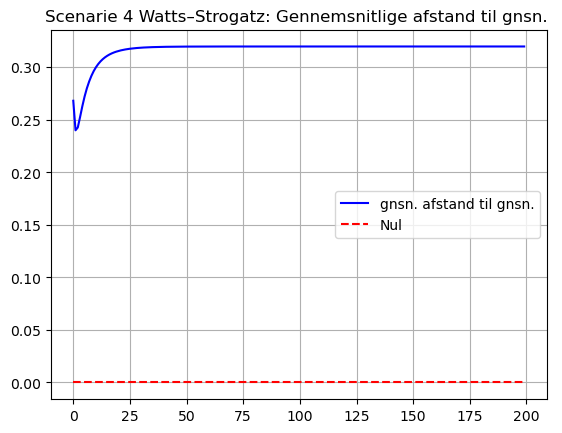

In [11]:
plt.figure()
plt.hist(ws_Scenarie4_startcond[ws_maskhumanScenarie4], bins=ws_binsScenarie4, alpha=0.4, label='Startbetingelser: 1')
plt.hist(ws_Scenarie4_endcond[ws_maskhumanScenarie4], bins=ws_binsScenarie4, alpha=0.4, label='Med polare medier der har hver sin halvdel: 2')
plt.xlim(-1, 1)
plt.legend()
plt.title('Scenarie 4 Watts–Strogatz: Holdningsfordeling ')
plt.show()


plt.figure()
plt.plot(np.arange(len(ws_Hoved_average_opinionresult)),ws_Hoved_average_opinionresult,'b-',label = 'gnsn. holdning')
plt.plot(np.arange(len(ws_Hoved_average_opinionresult)),np.zeros(len(ws_Hoved_average_opinionresult)),'r--',label = 'Nul')

plt.legend(loc = 'best')
plt.grid()
plt.title('Scenarie 4 Watts–Strogatz: Gennemsnitlige holdning over tid ')
plt.show()

plt.figure()
plt.plot(np.arange(len(ws_Hoved_average_distance_to_the_mean_result)),ws_Hoved_average_distance_to_the_mean_result,'b-',label = 'gnsn. afstand til gnsn.')
plt.plot(np.arange(len(ws_Hoved_average_distance_to_the_mean_result)),np.zeros(len(ws_Hoved_average_distance_to_the_mean_result)),'r--',label = 'Nul')

plt.legend()
plt.grid()
plt.title('Scenarie 4 Watts–Strogatz: Gennemsnitlige afstand til gnsn. ')
plt.show()

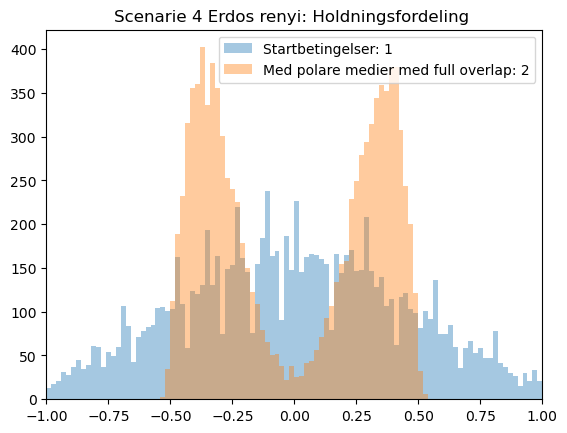

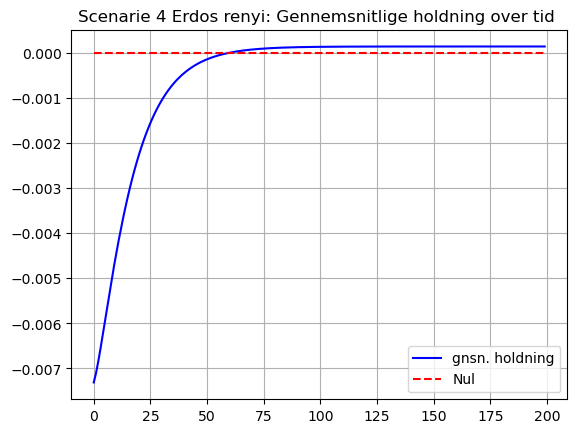

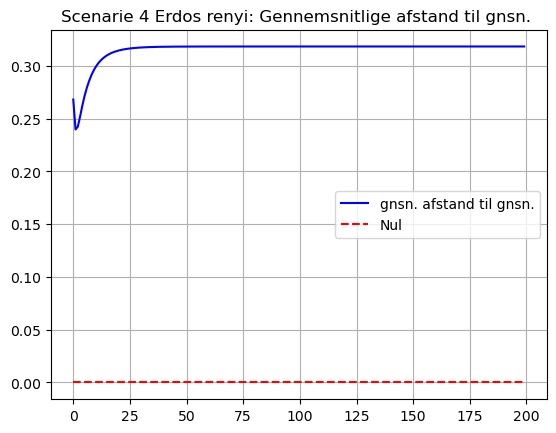

In [10]:
plt.figure()
plt.hist(er_Scenarie4_startcond[er_maskhumanScenarie4], bins=er_binsScenarie4, alpha=0.4, label='Startbetingelser: 1')
plt.hist(er_Scenarie4_endcond[er_maskhumanScenarie4], bins=er_binsScenarie4, alpha=0.4, label='Med polare medier med full overlap: 2')
plt.xlim(-1, 1)
plt.legend()
plt.title('Scenarie 4 Erdos renyi: Holdningsfordeling ')
plt.show()


plt.figure()
plt.plot(np.arange(len(er_Hoved_average_opinionresult)),er_Hoved_average_opinionresult,'b-',label = 'gnsn. holdning')
plt.plot(np.arange(len(er_Hoved_average_opinionresult)),np.zeros(len(er_Hoved_average_opinionresult)),'r--',label = 'Nul')

plt.legend(loc = 'best')
plt.grid()
plt.title('Scenarie 4 Erdos renyi: Gennemsnitlige holdning over tid ')
plt.show()

plt.figure()
plt.plot(np.arange(len(er_Hoved_average_distance_to_the_mean_result)),er_Hoved_average_distance_to_the_mean_result,'b-',label = 'gnsn. afstand til gnsn.')
plt.plot(np.arange(len(er_Hoved_average_distance_to_the_mean_result)),np.zeros(len(er_Hoved_average_distance_to_the_mean_result)),'r--',label = 'Nul')

plt.legend()
plt.grid()
plt.title('Scenarie 4 Erdos renyi: Gennemsnitlige afstand til gnsn. ')
plt.show()